### Random Forest Regression

Random Forest is a popular regression/classification algorithm for ML. Random forest is useful as lower correlation features are weighted less in the model, meaning the model fits extremely well to training data but can overfit if the settings are not properly calibrated.

In [1]:
# Cell 1 - Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../../style_Matplotlib_charts.mplstyle")
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pickle
import os

In [2]:
# Cell 2 - Load and store data
training_data = pd.read_csv('2.3.2.training_data.csv')

x_name = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    # "key",
    # "song_mode",
    "duration_ms",
]
y_name = "track_album_release_date"

x = np.array(training_data[x_name])
y = np.array(training_data[y_name])

print(f"Dataset loaded: {x.shape[0]} samples, {x.shape[1]} features")

Dataset loaded: 17385 samples, 11 features


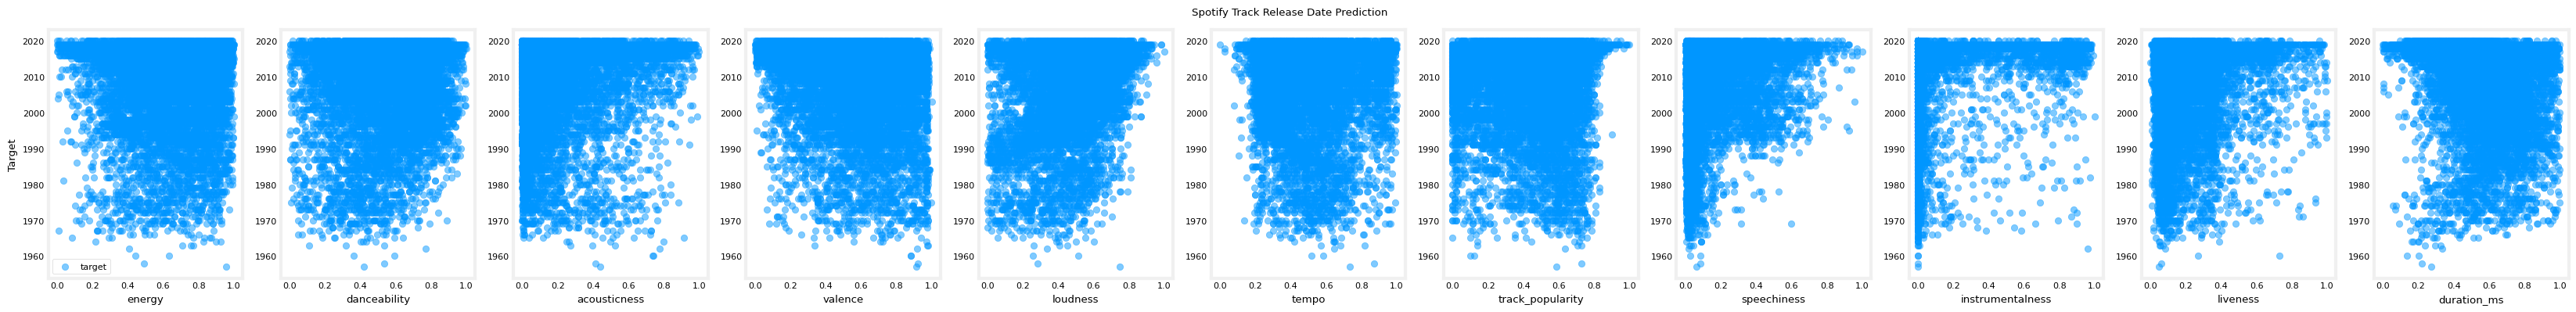

In [3]:
# Cell 3 - Plot features vs target
fig, ax = plt.subplots(1, len(x_name), figsize=(len(x_name) * 3, 4))
for i in range(len(ax)):
    ax[i].scatter(x[:, i], y, label='target', alpha=0.5)
    ax[i].set_xlabel(x_name[i])
ax[0].set_ylabel("Target")
ax[0].legend()
fig.suptitle("Spotify Track Release Date Prediction")
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 - Build and fit Random Forest model
my_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=None,     # let trees grow fully
    random_state=42
)
my_model.fit(x, y)

print(f"Number of trees: {my_model.n_estimators}")

Number of trees: 100


R:  0.9736
R²: 0.9193


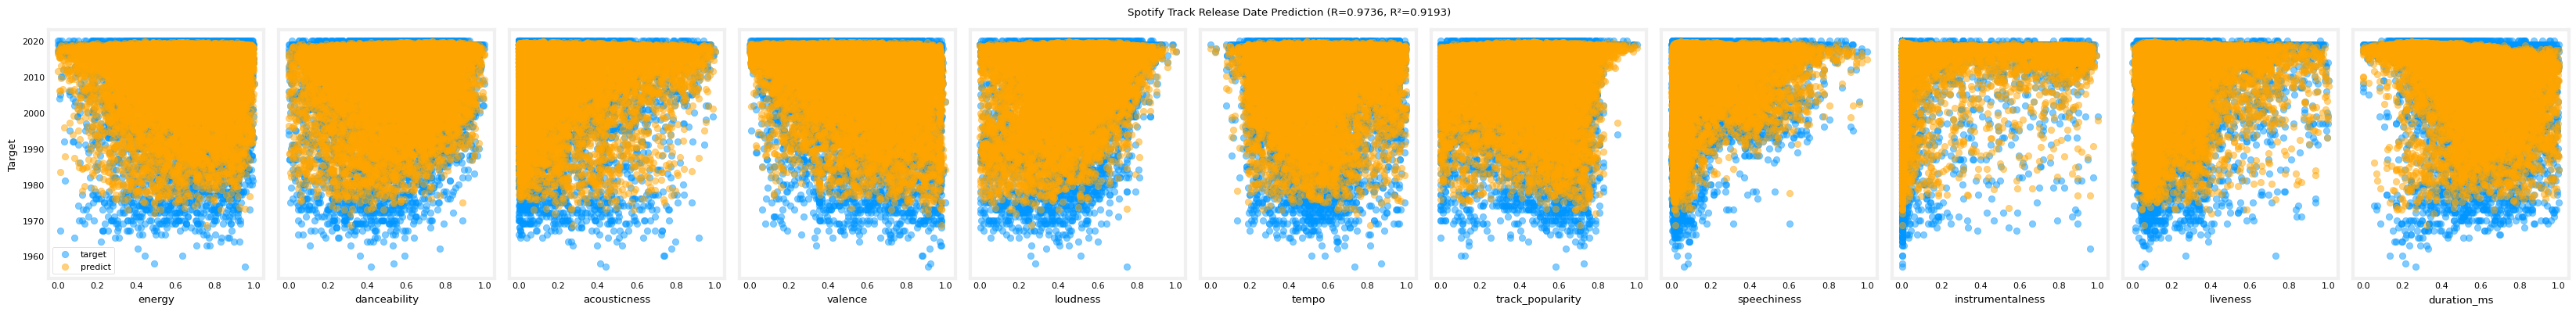

In [5]:
# Cell 5 - Evaluate and plot model
y_pred = my_model.predict(x)

r = np.corrcoef(y, y_pred)[0, 1]
r2 = r2_score(y, y_pred)

print(f"R:  {r:.4f}")
print(f"R²: {r2:.4f}")

fig, ax = plt.subplots(1, len(x_name), figsize=(len(x_name) * 3, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x[:, i], y, label="target", alpha=0.5)
    ax[i].scatter(x[:, i], y_pred, color="orange", label="predict", alpha=0.5)
    ax[i].set_xlabel(x_name[i])
ax[0].set_ylabel("Target")
ax[0].legend()
fig.suptitle(f"Spotify Track Release Date Prediction (R={r:.4f}, R²={r2:.4f})")
plt.tight_layout()
plt.show()

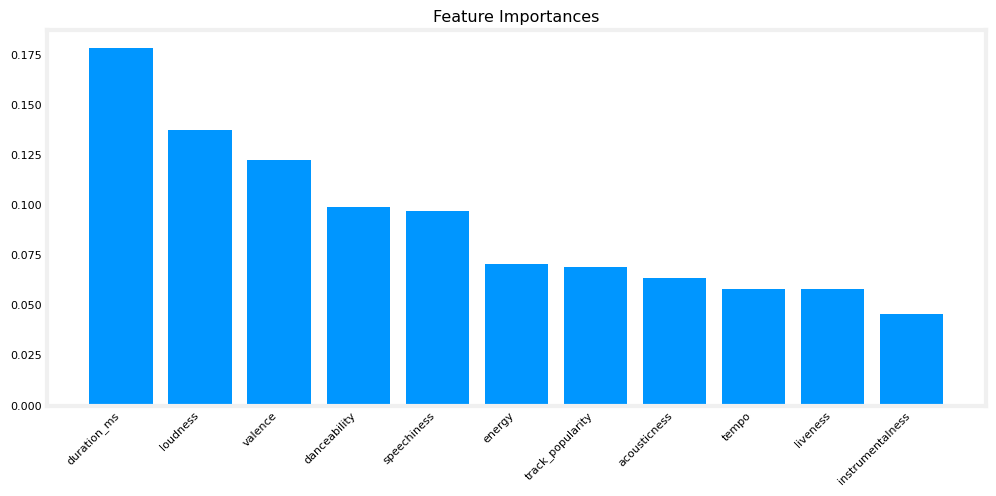


Feature Rankings:
  duration_ms               0.1784
  loudness                  0.1377
  valence                   0.1226
  danceability              0.0989
  speechiness               0.0969
  energy                    0.0705
  track_popularity          0.0693
  acousticness              0.0639
  tempo                     0.0581
  liveness                  0.0579
  instrumentalness          0.0459


In [6]:
# Cell 6 - Feature importance plot
importances = my_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(x_name)), importances[indices])
plt.xticks(range(len(x_name)), [x_name[i] for i in indices], rotation=45, ha='right')
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

print("\nFeature Rankings:")
for i in indices:
    print(f"  {x_name[i]:<25} {importances[i]:.4f}")

In [7]:
# Cell 7 - Save model
output_dir = '../2.4.Model_Testing_and_Validation/'
os.makedirs(output_dir, exist_ok=True)

model_filename = 'my_saved_model_v4.sav'
with open(os.path.join(output_dir, model_filename), 'wb') as f:
    pickle.dump(my_model, f)

print(f"Model saved: {output_dir + model_filename}")

Model saved: ../2.4.Model_Testing_and_Validation/my_saved_model_v4.sav
